# Floating Point Assignment

To run this notebook, use the provided file `floating_point_assignment.ipynb` and place it into your working directory.

```bash
source venv/bin/activate
jupyter lab --ip 0.0.0.0
```

Then, follow the link from the standard out of the command. This contains a token to provide you access. To turn in your work, save this notebook and provide the file.

## Definitions (25)

We will start with a definition of floating point and double using IEEE format definitions. They are

* 32-bit: 1 sign bit, 8 exp bits, 23 frac bits
* 64-bit: 1 sign bit, 11 exp bits, 52 frac bits
* 8-bit: 1 sign bit, 4 exp bits, 3 frac bits

1. Provide the representation of the value 3.14159265 in 32-bit IEEE format.
1. Provide the representation of the value 3.14159265 in 64-bit IEEE.
1. Provide the representation of the value 3.14159265 in the 8 bit format
1. Compare the precision loss of each value in comparison to 64-bit.
1. Choose a repeating number of your choosing (ie 1/3) and show the precision loss comparing the 8-bit format to 32-bit.

For numbers 1-3, provide your value in hex as that is easier. The above values should be completed by hand. You may use the techniques in part two to check your work.

## Precision (25)

In [1]:
import numpy as np
from pymap3d.ecef import geodetic2ecef

In this section, you will use latitude, longitude, altitude coordinates to perform some calculations. The first is a coordinate change into Earth Centered, Earth Fixed (ECEF). You will then use a method for calculating the euclidean distance. You will then make observations on the precision of your calculations using three different floating point definitions. I have chosen UCCS and UC Boulder as examples. Replace at least one of these locations with those that you choose.

### Points (5 points each)

1. Replace location coordinates
2. Perform calculations with each of `np.float64`, `np.float32`, and `np.float16`
3. Brief discussion of observations

In [2]:
help(geodetic2ecef)

Help on function geodetic2ecef in module pymap3d.ecef:

geodetic2ecef(lat, lon, alt, ell: 'Ellipsoid | None' = None, deg: 'bool' = True) -> 'tuple'
    point transformation from Geodetic of specified ellipsoid (default WGS-84) to ECEF
    
    Parameters
    ----------
    
    lat
           target geodetic latitude
    lon
           target geodetic longitude
    alt
         target altitude above geodetic ellipsoid (meters)
    ell : Ellipsoid, optional
          reference ellipsoid
    deg : bool, optional
          degrees input/output  (False: radians in/out)
    
    
    Returns
    -------
    
    ECEF (Earth centered, Earth fixed)  x,y,z
    
    x
        target x ECEF coordinate (meters)
    y
        target y ECEF coordinate (meters)
    z
        target z ECEF coordinate (meters)



In [3]:
help(np.linalg.norm)

Help on _ArrayFunctionDispatcher in module numpy.linalg:

norm(x, ord=None, axis=None, keepdims=False)
    Matrix or vector norm.
    
    This function is able to return one of eight different matrix norms,
    or one of an infinite number of vector norms (described below), depending
    on the value of the ``ord`` parameter.
    
    Parameters
    ----------
    x : array_like
        Input array.  If `axis` is None, `x` must be 1-D or 2-D, unless `ord`
        is None. If both `axis` and `ord` are None, the 2-norm of
        ``x.ravel`` will be returned.
    ord : {non-zero int, inf, -inf, 'fro', 'nuc'}, optional
        Order of the norm (see table under ``Notes``). inf means numpy's
        `inf` object. The default is None.
    axis : {None, int, 2-tuple of ints}, optional.
        If `axis` is an integer, it specifies the axis of `x` along which to
        compute the vector norms.  If `axis` is a 2-tuple, it specifies the
        axes that hold 2-D matrices, and the matrix nor

#### 64-bit

In [4]:
uccs_64 = np.array([38.8936117,-104.8005516, 1965.96])
ucb_64 = np.array([40.0073943,-105.2662901, 1661.16])

In [5]:
uccs_64_ecef = np.array([*geodetic2ecef(*uccs_64)])
uccs_64_ecef

array([-1270194.52877575, -4807305.93880946,  3984365.91566153])

In [6]:
ucb_64_ecef = np.array([*geodetic2ecef(*ucb_64)])
ucb_64_ecef

array([-1288472.91829674, -4720774.50988504,  4079682.41622987])

In [7]:
np.linalg.norm(uccs_64_ecef - ucb_64_ecef)

130027.0087165725

#### 32-bit

In [8]:
uccs_32 = uccs_64.astype(np.float32)
ucb_32 = ucb_64.astype(np.float32)

In [9]:
uccs_32_ecef = np.array([*geodetic2ecef(*uccs_32)])
uccs_32_ecef

array([-1270194.43542948, -4807306.06965539,  3984365.91329425])

In [10]:
ucb_32_ecef = np.array([*geodetic2ecef(*ucb_32)])
ucb_32_ecef

array([-1288472.69727239, -4720774.64402719,  4079682.24881102])

In [11]:
np.linalg.norm(uccs_32_ecef - ucb_32_ecef)

130026.86758355772

#### 16-bit

In [12]:
# Complete on your own
uccs_16 = uccs_64.astype(np.float16)
ucb_16 = ucb_64.astype(np.float16)
uccs_16_ecef = np.array([*geodetic2ecef(*uccs_16)])
uccs_16_ecef

array([-1269426.08483311, -4805857.83550585,  3986067.67189837])

In [13]:
ucb_16_ecef = np.array([*geodetic2ecef(*ucb_16)])
ucb_16_ecef

array([-1286638.41692808, -4721258.14642504,  4079878.63704478])

In [14]:
np.linalg.norm(uccs_16_ecef - ucb_16_ecef)

127490.66220870965

#### Discussion

Since 16 bit floats only have 1 sign bit, 5 exponent bits, and 10 mantissa bits this leads to less accuracy. This will cause increased rounding errors in the floating point numbers. The 32 bit numbers have 1 sign bit, 8 exponent bits, and 23 mantissa bits which leads to using more memory but has a higher precision. The 64 bit floats have 1 sing bit, 11 exponent bits, and 52 mantissa bits which is double the memory requirements as the 32 bit floats but also provides more precision. You can see the number change from 130027 to 130026 between the 64 and 32 bit floats but when switching to 16 bit floats it drop tremendously due to the rounding errors and less precision.

## Number Line (10)

On a number line, place a sequence of at least 10 numbers (both +/-), along with the largest possible value (+/-) represented in the 8-bit tiny notation. You may choose the numbers yourself. You should observe the distance between the numbers, and make some comments.  Here is an example of two numbers:

In [15]:
import matplotlib.pyplot as plt

In [16]:
x = np.array([-10.5, -0.5, 0.5, 1.5, -1.5, 2.5, -2.5, 3.5, -3.5, 4.5, -4.5, 9.5, -9.5, 9.6, -9.6, 10.5])
y = np.zeros_like(x)

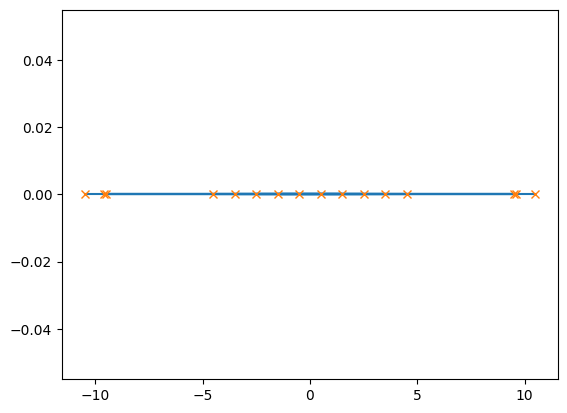

In [17]:
plt.plot(x, y);
plt.plot(x, y, 'x');

#### Discussion

The spaces between the numbers that are closer to zero is closer than the spacing of numbers that are farther away from zero. This is because of the logarithmic structure of floating point numbers. There is also only 8 bits of accuracy so some numbers cant be exactly represented in 8 bits which causes rounding errors.

## Quantization (25)

You will perform quantization of an image using different quantization levels. Quantization can take many forms. This project will focus on image quantization. Refer to the Wikipedia page on [Quantization](https://en.wikipedia.org/wiki/Quantization_(image_processing)). To start, we will have to convert an image from color with RGB to grayscale. We will use the weights defined with by following [equation](https://en.wikipedia.org/wiki/Grayscale):
$$Y_{linear} = 0.2126R_{linear} + 0.7152G_{linear} + 0.0722B_{linear}$$

To ensure that we stay in the common 8-bit grayscale range we will use `np.uint8` for all calculated arrays.


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

Let's take a look at our starting image for reference. Replacing the image is encouraged once the example has been proven to work.

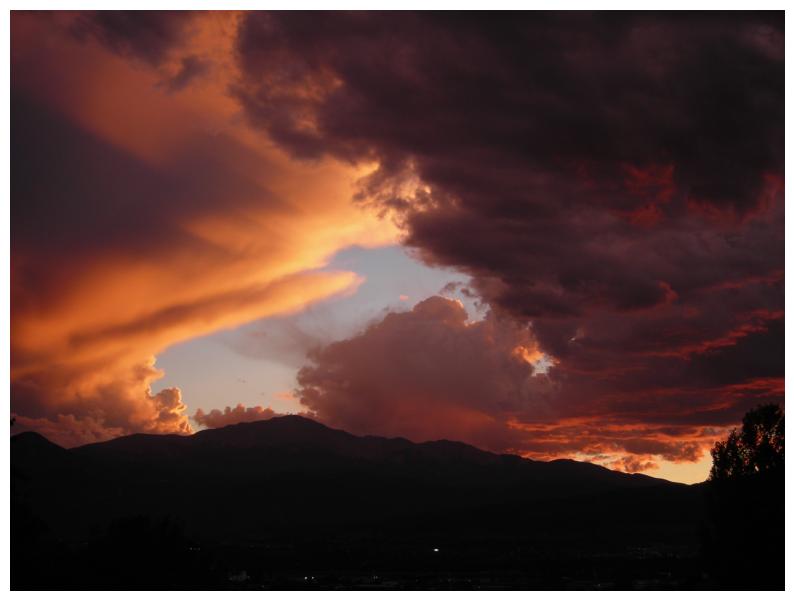

In [19]:
img = mpimg.imread('DSCN8380_2.JPG')
plt.figure(figsize=[10,8])
plt.imshow(img)
plt.axis('off')
plt.show()

Let's take a look at the shape of the data. We should be able to relate indexes 0, 1, and 2 as the intensity values for channels red, green, and blue.

In [20]:
img.shape

(1944, 2592, 3)

In [21]:
img_grayscale = np.empty((img.shape[0], img.shape[1]), dtype=np.uint8)
img_grayscale[:] = 0.2126 * img[:, :, 0] + 0.7152 * img[:, :, 1] + 0.0722 * img[:, :, 2]

Let's view the grayscaled image. Note the shape of our image is the pixel dimensions.

In [22]:
img_grayscale.shape, img_grayscale.dtype

((1944, 2592), dtype('uint8'))

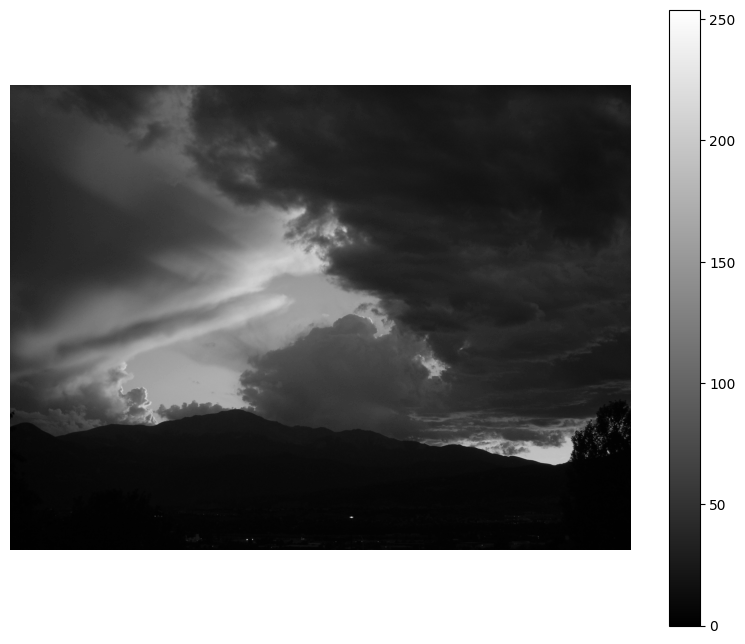

In [23]:
plt.figure(figsize=[10,8])
plt.imshow(img_grayscale, cmap='gray')
plt.colorbar()
plt.axis('off')
plt.show()

The formula for uniform quantization is:
$$Q(x) = \lfloor \frac{x}{\Delta} \rfloor \times \Delta + \frac{\Delta}{2}$$
Where $\Delta$ is defined as:
$$\Delta = \frac{255}{L -1}$$
Let's set up to quantize with $L = 3$.

In [24]:
rgb_max = 255
L = 3
delta = rgb_max / (L - 1)
delta

127.5

In [25]:
img_q_l3 = np.empty((img.shape[0], img.shape[1]), dtype=np.uint8)
img_q_l3[:] = np.floor(img_grayscale / delta) * delta + delta / 2

Let's take a look at how our image looks when quantized with $L = 3$.

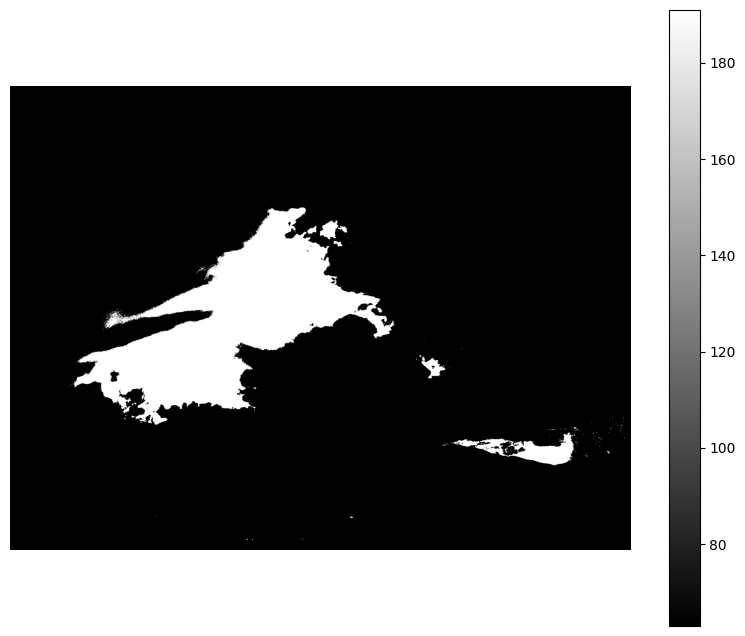

In [26]:
plt.figure(figsize=[10,8])
plt.imshow(img_q_l3, cmap='gray')
plt.colorbar()
plt.axis('off')
plt.show()

#### Discussion (10)

1. How does the image appear to you?
The image looks all black with white areas in the middle of the image

2. How many bits does it take to store L = 3?
We would need to take the log of 3 to find this which comes out to about 1.5 bits but we cannot use partial bits so we would have to use 2 bits to represent L=3.

### Custom Quantization (5)

Choose a quantization level $L$ to your satisfaction and display your image.

In [27]:
rgb_max = 255
L = 16
delta = rgb_max / (L - 1)
delta

17.0

In [28]:
img_q_custom = np.empty((img.shape[0], img.shape[1]), dtype=np.uint8)
img_q_custom[:] = np.floor(img_grayscale / delta) * delta + delta / 2

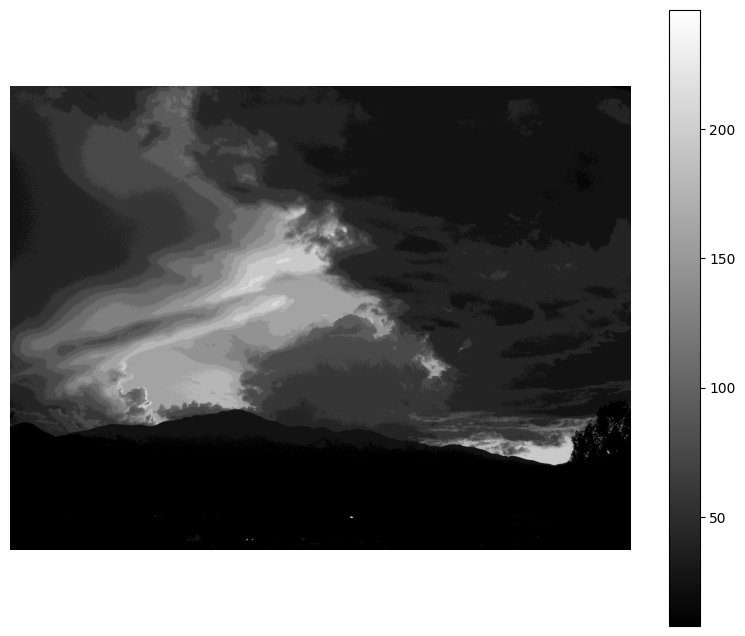

In [29]:
plt.figure(figsize=[10,8])
plt.imshow(img_q_custom, cmap='gray')
plt.colorbar()
plt.axis('off')
plt.show()

#### Discussion (10)

1. How many bits would it take to encode the new quantization level $L$?
I chose L=16 so the base 2 log of 16 give me 4 bits needed to represent L=16.

2. What types of devices might benefit from using quantization? (Be creative!)
Probably crime stoppers because they always have some grainy awful image of a criminal that doesnt help anything. This could potentially help make the image more clear. In reinforcement learning also there is a performance benefit from storing the model weights as 4 bit weights instead of 16 bit weights which dramatically saves compute time. If I have a model that has 120 billion parameters and I save 12 bits on 120 billion parameters that is a huge efficiency increase and reduces training and finetuning times.

In [32]:
from PIL.ExifTags import TAGS
from PIL import Image
img = Image.open("DSCN8380_2.JPG")
exif_data = img._getexif()
for key_id, value in exif_data.items():
    if TAGS.get(key_id, key_id) == 'DateTimeOriginal':
        print(f"The photo was taken at: {value}")

print("I was unable to find location metadata in the photo")

The photo was taken at: 2010:08:31 17:44:29
I was unable to find location metadata in the photo
